# Module 3 — Exercise: Unsupervised Clustering → Sigma Rules (DNS/Network Logs)

**Learning goals**
- Load and inspect a real export (`zeek5.csv`)
- Compute descriptive statistics (numeric + categorical)
- Run **DBSCAN** and **HDBSCAN** to find rare-event clusters
- Compare clusterings and extract **actionable insights**
- Draft **detection rules** (Sigma + IDS/Firewall ideas) from anomaly clusters


## 1) Load the dataset & show column names

In [2]:
import pandas as pd, os, csv, json
DATA_PATH = r"./zeek5.csv"
assert os.path.exists(DATA_PATH), f"Dataset not found at {DATA_PATH}"

def load_csv_robust(path):
    try:
        return pd.read_csv(path, low_memory=False)
    except Exception as e1:
        print("Fast parser failed:", e1)
    try:
        return pd.read_csv(path, engine="python", sep=None, quoting=csv.QUOTE_MINIMAL, escapechar="\\", on_bad_lines="warn", low_memory=False)
    except Exception as e2:
        print("Python engine (sep=None) failed:", e2)
    try:
        return pd.read_csv(path, engine="python", sep=",", quoting=csv.QUOTE_MINIMAL, escapechar="\\", on_bad_lines="skip", low_memory=False)
    except Exception as e3:
        print("Forced comma failed:", e3)
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line=line.strip()
            if not line: continue
            rows.append(json.loads(line))
    return pd.json_normalize(rows)

df = load_csv_robust(DATA_PATH)
print("Rows, Cols:", df.shape)
print("Column names:")
for i,c in enumerate(df.columns, 1):
    print(f"  {i:02d}. {c}")
df.head(5)

Rows, Cols: (2252, 8)
Column names:
  01. @timestamp
  02. destination.ip
  03. destination.port
  04. dns.answers.ttl
  05. dns.header_flags
  06. dns.question.name
  07. source.ip
  08. source.port


,@timestamp,destination.ip,destination.port,dns.answers.ttl,dns.header_flags,dns.question.name,source.ip,source.port
0,"Oct 19, 2025 @ 23:33:45.359",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353
1,"Oct 19, 2025 @ 23:33:45.358",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353
2,"Oct 19, 2025 @ 23:33:45.355",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353
3,"Oct 19, 2025 @ 23:33:45.354",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353
4,"Oct 19, 2025 @ 23:33:11.943",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353


## 2) Descriptive statistics
- Numeric columns: count, mean, std, min, quartiles, max
- Categorical columns: top values
- Optional: timestamp coverage


In [3]:
import numpy as np
TS_CANDIDATES = ['ts','@timestamp','event.created','event.ingested','timestamp']
ts_col = next((c for c in TS_CANDIDATES if c in df.columns), None)

if ts_col:
    ts = pd.to_datetime(df[ts_col], errors='coerce')
    print("Time coverage:", ts.min(), "→", ts.max())
else:
    print("No explicit timestamp column found among:", TS_CANDIDATES)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns (", len(num_cols), "):", num_cols)
if num_cols:
    display(df[num_cols].describe().T)

non_num_cols = [c for c in df.columns if c not in num_cols]
print("\nCategorical/string columns (sampled top 10 values each):", len(non_num_cols))
shown = 0
for c in non_num_cols:
    try:
        print(f"\nTop values for: {c}")
        display(df[c].astype(str).value_counts(dropna=False).head(10))
        shown += 1
        if shown >= 12:
            print("\n… (showing first 12 categorical columns; inspect others manually if needed)")
            break
    except Exception:
        pass


C:\Users\emrec\AppData\Local\Temp\ipykernel_15308\3228411477.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ts = pd.to_datetime(df[ts_col], errors='coerce')


Time coverage: NaT → NaT

Numeric columns ( 2 ): ['destination.port', 'source.port']


,count,mean,std,min,25%,50%,75%,max
destination.port,2252.0,2340.758437,2623.344960,53.0,53.0,53.0,5353.0,5355.0
source.port,2252.0,30964.831705,21422.611333,5353.0,5353.0,38376.5,49922.5,63817.0



Categorical/string columns (sampled top 10 values each): 6

Top values for: @timestamp


@timestamp
Oct 19, 2025 @ 10:10:53.193    15
Oct 19, 2025 @ 10:11:02.405    15
Oct 19, 2025 @ 10:10:48.209    13
Oct 19, 2025 @ 11:04:12.811     4
Oct 19, 2025 @ 16:11:41.364     3
Oct 19, 2025 @ 10:28:20.294     3
Oct 19, 2025 @ 11:04:12.820     3
Oct 19, 2025 @ 10:04:11.913     3
Oct 19, 2025 @ 22:37:45.953     3
Oct 19, 2025 @ 17:51:38.888     2
Name: count, dtype: int64

...

dns.header_flags
RD        1211
AA         853
-          184
AA, RD       4
Name: count, dtype: int64


Top values for: dns.question.name


dns.question.name
ech-rog.local             817
*                          66
ech-rog                    58
win-sivms1g7j74.local      36
win-sivms1g7j74            36
microsoft.com              29
google.com                 29
cloudflare.com             24
_googlecast._tcp.local     24
openai.com                 23
Name: count, dtype: int64


Top values for: source.ip


source.ip
192.168.56.2                 1281
192.168.56.1                  473
fe80::b6e0:cf17:dce3:e507     426
fe80::3aca:a7f1:9332:a384      36
192.168.56.3                   36
Name: count, dtype: int64

### 2.1 Optional feature engineering (if columns exist)
- Query normalization, length, entropy
- rcode-based failure ratio
- Hourly window key


In [4]:
from collections import Counter
from scipy.stats import entropy as shannon
import re

def str_entropy(s: str) -> float:
    if not isinstance(s, str) or len(s) == 0:
        return 0.0
    cnt = Counter(s)
    probs = np.array(list(cnt.values()), dtype=float) / float(len(s))
    return float(shannon(probs, base=2))

# Columns available in this dataset: '@timestamp', 'destination.ip', 'destination.port',
# 'dns.answers.ttl', 'dns.header_flags', 'dns.question.name', 'source.ip', 'source.port'
QUERY_CAND = ['query','zeek.dns.query','dns.question.name','dns.qname','dns.query']
HEADER_FLAGS_CAND = ['dns.header_flags']
ANSWERS_TTL_CAND = ['dns.answers.ttl']
RCODE_CAND = ['rcode','zeek.dns.rcode','dns.response_code','dns.rcode']  # kept as fallback

q_col = next((c for c in QUERY_CAND if c in df.columns), None)
h_col = next((c for c in HEADER_FLAGS_CAND if c in df.columns), None)
ttl_col = next((c for c in ANSWERS_TTL_CAND if c in df.columns), None)
r_col = next((c for c in RCODE_CAND if c in df.columns), None)

if q_col:
    df['query_norm'] = df[q_col].fillna('').astype(str).str.lower().str.strip().str.rstrip('.')
    df['query_len'] = df['query_norm'].str.len().fillna(0).astype(int)
    df['query_entropy'] = df['query_norm'].apply(str_entropy)
    print("Added: query_norm, query_len, query_entropy (from", q_col, ")")
else:
    print("No query column found; skipping query-based features.")

# Helper to extract rcode from dns.header_flags like "qr|rd|ra|rcode=3" if present
def parse_rcode_from_flags(s):
    if not isinstance(s, str):
        return None
    m = re.search(r'rcode=(\d+)', s)
    if m:
        try:
            return int(m.group(1))
        except:
            return None
    return None

# Derive is_failed: prefer explicit rcode in header_flags, else use dns.answers.ttl presence
if h_col:
    df['dns_header_flags'] = df[h_col].astype(str)
    df['rcode_extracted'] = df['dns_header_flags'].apply(parse_rcode_from_flags)
    # rcode_extracted None -> treat as unknown (assume success 0); numeric 0 -> success, else failure
    def _rcode_to_failed(x):
        if x is None or x == '':
            return 0
        try:
            return 0 if int(x) == 0 else 1
        except:
            return 1
    df['is_failed'] = df['rcode_extracted'].apply(_rcode_to_failed).astype(int)
    df['rcode_norm'] = df['rcode_extracted'].fillna('').astype(str)
    print("Added: dns_header_flags, rcode_extracted, rcode_norm, is_failed (from", h_col, ")")

elif r_col:
    df['rcode_norm'] = df[r_col].astype(str)
    df['is_failed'] = df['rcode_norm'].map(lambda x: 0 if str(x).strip().upper() in ['0','NOERROR','NONE','NAN'] else 1).astype(int)
    print("Added: rcode_norm, is_failed (from", r_col, ")")

elif ttl_col:
    # If answers TTL > 0 assume a positive answer (not failed); else mark as failed
    df[ttl_col] = pd.to_numeric(df[ttl_col], errors='coerce')
    df['is_failed'] = df[ttl_col].fillna(0).apply(lambda x: 0 if x > 0 else 1).astype(int)
    print("Added: is_failed (derived from", ttl_col, ")")

else:
    df['is_failed'] = 0
    print("No header_flags/rcode/answers.ttl column found; defaulting is_failed=0")

TS_CANDIDATES = ['ts','@timestamp','event.created','event.ingested','timestamp']
ts_col = next((c for c in TS_CANDIDATES if c in df.columns), None)
if ts_col:
    df['_hour'] = pd.to_datetime(df[ts_col], errors='coerce').dt.floor('H')
    print("Added _hour for hourly aggregation (from", ts_col, ")")
else:
    df['_hour'] = pd.NaT

Added: query_norm, query_len, query_entropy (from dns.question.name )
Added: dns_header_flags, rcode_extracted, rcode_norm, is_failed (from dns.header_flags )


C:\Users\emrec\AppData\Local\Temp\ipykernel_15308\794718427.py:78: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['_hour'] = pd.to_datetime(df[ts_col], errors='coerce').dt.floor('H')


Added _hour for hourly aggregation (from @timestamp )


C:\Users\emrec\AppData\Local\Temp\ipykernel_15308\794718427.py:78: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['_hour'] = pd.to_datetime(df[ts_col], errors='coerce').dt.floor('H')


### 2.2 Build aggregation table for clustering

In [5]:
SRC_CAND = ['src_ip','source.ip','client.ip','id.orig_h','network.client.ip']
src_col = next((c for c in SRC_CAND if c in df.columns), None)

# Determine grouping: prefer src + hour if both available, else hour, else src, else global
if src_col and df['_hour'].notna().any():
    group_cols = [src_col, '_hour']
elif df['_hour'].notna().any():
    group_cols = ['_hour']
elif src_col:
    group_cols = [src_col]
else:
    group_cols = []

df['__dummy__'] = 1
agg_parts = {'rows': ('__dummy__','count')}
if 'query_norm' in df.columns:
    agg_parts['queries'] = ('query_norm','count')
    agg_parts['unique_domains'] = ('query_norm','nunique')
if 'query_len' in df.columns:
    agg_parts['mean_query_len'] = ('query_len','mean')
    agg_parts['max_query_len'] = ('query_len','max')
if 'query_entropy' in df.columns:
    agg_parts['mean_entropy'] = ('query_entropy','mean')
if 'is_failed' in df.columns:
    agg_parts['failed_ratio'] = ('is_failed','mean')

if group_cols:
    agg = df.groupby(group_cols).agg(**agg_parts).reset_index()
else:
    agg = df.agg({k:v[1] for k,v in agg_parts.items()}).to_frame().T

agg = agg.drop(columns=['__dummy__'], errors='ignore')
print("Aggregation key:", group_cols if group_cols else "(global)")
print("Feature table shape:", agg.shape)
display(agg.head(10))

Aggregation key: ['source.ip']
Feature table shape: (5, 8)


,source.ip,rows,queries,unique_domains,mean_query_len,max_query_len,mean_entropy,failed_ratio
0,192.168.56.1,473,473,3,12.879493,22,3.213435,0.0
1,192.168.56.2,1281,1281,944,37.277908,249,3.738339,0.0
2,192.168.56.3,36,36,2,18.000000,21,3.759128,0.0
3,fe80::3aca:a7f1:9332:a384,36,36,2,18.000000,21,3.759128,0.0
4,fe80::b6e0:cf17:dce3:e507,426,426,3,12.823944,22,3.215047,0.0


## 3) DBSCAN (rare events as noise = -1)

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

numeric_feats = agg.select_dtypes(include=['number','float','int']).columns.tolist()
X = agg[numeric_feats].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

db = DBSCAN(eps=0.7, min_samples=5)
labels_db = db.fit_predict(X_scaled)
agg['dbscan_label'] = labels_db
print(agg['dbscan_label'].value_counts().sort_index())

dbscan_label
-1    5
Name: count, dtype: int64


In [7]:
# quick overview: counts + examples for noise (-1) and cluster 5
print(agg['dbscan_label'].value_counts().sort_index())

for lab in [-1, 5]:
    mask = agg['dbscan_label'] == lab
    print(f"\nLabel {lab}: {mask.sum()} rows")
    display(agg.loc[mask].sort_values(by='rows', ascending=False).head(10))
    

dbscan_label
-1    5
Name: count, dtype: int64

Label -1: 5 rows


,source.ip,rows,queries,unique_domains,mean_query_len,max_query_len,mean_entropy,failed_ratio,dbscan_label
1,192.168.56.2,1281,1281,944,37.277908,249,3.738339,0.0,-1
0,192.168.56.1,473,473,3,12.879493,22,3.213435,0.0,-1
4,fe80::b6e0:cf17:dce3:e507,426,426,3,12.823944,22,3.215047,0.0,-1
2,192.168.56.3,36,36,2,18.000000,21,3.759128,0.0,-1
3,fe80::3aca:a7f1:9332:a384,36,36,2,18.000000,21,3.759128,0.0,-1



Label 5: 0 rows


,source.ip,rows,queries,unique_domains,mean_query_len,max_query_len,mean_entropy,failed_ratio,dbscan_label


In [8]:
# If agg was grouped, map cluster rows back to original df using shared grouping columns
group_keys = [c for c in agg.columns if c in df.columns]
if group_keys:
    print("Group keys detected:", group_keys)
    noise_keys = agg[agg['dbscan_label'] == -1][group_keys].drop_duplicates()
    sample_noise_rows = df.merge(noise_keys, on=group_keys, how='inner').head(20)
    print("Sample original rows contributing to DBSCAN noise:")
    display(sample_noise_rows)
else:
    print("No group keys found in agg -> agg is a global aggregation; cannot map back to raw rows.")

Group keys detected: ['source.ip']
Sample original rows contributing to DBSCAN noise:


,@timestamp,destination.ip,destination.port,dns.answers.ttl,dns.header_flags,dns.question.name,source.ip,source.port,query_norm,query_len,query_entropy,dns_header_flags,rcode_extracted,is_failed,rcode_norm,_hour,__dummy__
0,"Oct 19, 2025 @ 23:33:45.359",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
1,"Oct 19, 2025 @ 23:33:45.358",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
2,"Oct 19, 2025 @ 23:33:45.355",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
3,"Oct 19, 2025 @ 23:33:45.354",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
4,"Oct 19, 2025 @ 23:33:11.943",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
5,"Oct 19, 2025 @ 23:33:11.942",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
6,"Oct 19, 2025 @ 23:33:11.940",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
7,"Oct 19, 2025 @ 23:33:11.940",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
8,"Oct 19, 2025 @ 23:30:37.575",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
9,"Oct 19, 2025 @ 23:30:37.575",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1


In [9]:
# Compare numeric feature stats for noise vs cluster 5
num = numeric_feats  # from your notebook
print("Feature means (noise vs cluster 5):")
display(agg.loc[agg['dbscan_label'].isin([-1,5])].groupby('dbscan_label')[num].agg(['count','mean','std']).T)

Feature means (noise vs cluster 5):


dbscan_label                  -1
rows           count    5.000000
               mean   450.400000
               std    508.541345
queries        count    5.000000
               mean   450.400000
               std    508.541345
unique_domains count    5.000000
               mean   190.800000
               std    421.051897
mean_query_len count    5.000000
               mean    19.796269
               std     10.105889
max_query_len  count    5.000000
               mean    67.000000
               std    101.742322
mean_entropy   count    5.000000
               mean     3.537015
               std      0.294774
failed_ratio   count    5.000000
               mean     0.000000
               std      0.000000

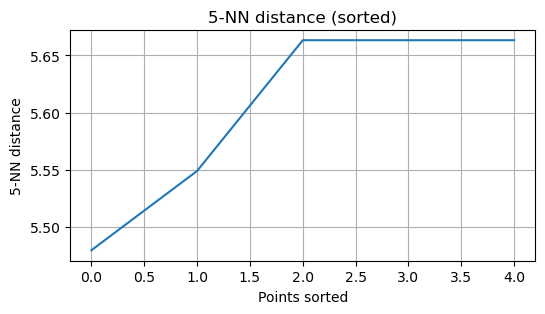

Mean k-dist (requested labels):
              mean_kdist
dbscan_label            
-1               5.60369
 5                   NaN
Note: these labels are not present in the clustering result: [5]

Top 10 noise groups by kdist:


,source.ip,rows,queries,unique_domains,mean_query_len,max_query_len,mean_entropy,failed_ratio,dbscan_label,kdist
1,192.168.56.2,1281,1281,944,37.277908,249,3.738339,0.0,-1,5.663283
2,192.168.56.3,36,36,2,18.000000,21,3.759128,0.0,-1,5.663283
3,fe80::3aca:a7f1:9332:a384,36,36,2,18.000000,21,3.759128,0.0,-1,5.663283
4,fe80::b6e0:cf17:dce3:e507,426,426,3,12.823944,22,3.215047,0.0,-1,5.548959
0,192.168.56.1,473,473,3,12.879493,22,3.213435,0.0,-1,5.479642



Top 10 noise groups by rows:


,source.ip,rows,queries,unique_domains,mean_query_len,max_query_len,mean_entropy,failed_ratio,dbscan_label,kdist
1,192.168.56.2,1281,1281,944,37.277908,249,3.738339,0.0,-1,5.663283
0,192.168.56.1,473,473,3,12.879493,22,3.213435,0.0,-1,5.479642
4,fe80::b6e0:cf17:dce3:e507,426,426,3,12.823944,22,3.215047,0.0,-1,5.548959
2,192.168.56.3,36,36,2,18.000000,21,3.759128,0.0,-1,5.663283
3,fe80::3aca:a7f1:9332:a384,36,36,2,18.000000,21,3.759128,0.0,-1,5.663283



Mapping sample noise groups back to raw rows using group keys: ['source.ip']


,@timestamp,destination.ip,destination.port,dns.answers.ttl,dns.header_flags,dns.question.name,source.ip,source.port,query_norm,query_len,query_entropy,dns_header_flags,rcode_extracted,is_failed,rcode_norm,_hour,__dummy__
0,"Oct 19, 2025 @ 23:33:45.359",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
1,"Oct 19, 2025 @ 23:33:45.358",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
2,"Oct 19, 2025 @ 23:33:45.355",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
3,"Oct 19, 2025 @ 23:33:45.354",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
4,"Oct 19, 2025 @ 23:33:11.943",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
5,"Oct 19, 2025 @ 23:33:11.942",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
6,"Oct 19, 2025 @ 23:33:11.940",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
7,"Oct 19, 2025 @ 23:33:11.940",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
8,"Oct 19, 2025 @ 23:30:37.575",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
9,"Oct 19, 2025 @ 23:30:37.575",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1



Feature means (present labels):


dbscan_label                  -1
rows           count    5.000000
               mean   450.400000
               std    508.541345
queries        count    5.000000
               mean   450.400000
               std    508.541345
unique_domains count    5.000000
               mean   190.800000
               std    421.051897
mean_query_len count    5.000000
               mean    19.796269
               std     10.105889
max_query_len  count    5.000000
               mean    67.000000
               std    101.742322
mean_entropy   count    5.000000
               mean     3.537015
               std      0.294774
failed_ratio   count    5.000000
               mean     0.000000
               std      0.000000

In [11]:
# k-distance plot to inspect a good eps and see why points are noise
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

n_neighbors = max(2, db.min_samples if hasattr(db, 'min_samples') else 5)
nn = NearestNeighbors(n_neighbors=n_neighbors).fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
kdist = np.sort(distances[:, -1])

plt.figure(figsize=(6,3))
plt.plot(kdist)
plt.title(f'{n_neighbors}-NN distance (sorted)')
plt.ylabel(f'{n_neighbors}-NN distance')
plt.xlabel('Points sorted')
plt.grid(True)
plt.show()

# attach k-dist back to agg and compare averages (robust to missing labels)
agg_k = agg.copy()
agg_k['kdist'] = distances[:, -1]

mean_kdist = agg_k.groupby('dbscan_label')['kdist'].mean()
desired = [-1, 5]
print("Mean k-dist (requested labels):")
print(mean_kdist.reindex(desired).to_frame(name='mean_kdist').fillna(np.nan))

missing = [l for l in desired if l not in mean_kdist.index]
if missing:
    print("Note: these labels are not present in the clustering result:", missing)

# show top noise groups by kdist and by rows
if -1 in agg_k['dbscan_label'].values:
    print("\nTop 10 noise groups by kdist:")
    display(agg_k[agg_k['dbscan_label'] == -1].sort_values('kdist', ascending=False).head(10))
    print("\nTop 10 noise groups by rows:")
    display(agg_k[agg_k['dbscan_label'] == -1].sort_values('rows', ascending=False).head(10))
else:
    print("\nNo DBSCAN noise (-1) present in agg_k.")

# map back to raw df rows if grouping keys exist
group_keys = [c for c in agg.columns if c in df.columns]
if group_keys and -1 in agg_k['dbscan_label'].values:
    print("\nMapping sample noise groups back to raw rows using group keys:", group_keys)
    noise_keys = agg_k[agg_k['dbscan_label'] == -1][group_keys].drop_duplicates()
    sample_noise_rows = df.merge(noise_keys, on=group_keys, how='inner').head(30)
    display(sample_noise_rows)
else:
    if not group_keys:
        print("\nNo group keys available to map back to raw rows (agg was global).")
    else:
        print("\nNo noise groups to map back to raw rows.")

# quick feature comparison (robust selection)
num = numeric_feats
present_labels = [l for l in desired if l in agg_k['dbscan_label'].unique()]
if present_labels:
    print("\nFeature means (present labels):")
    display(agg_k.loc[agg_k['dbscan_label'].isin(present_labels)].groupby('dbscan_label')[num].agg(['count','mean','std']).T)
else:
    print("\nNone of the requested labels are present for feature comparison.")

DBSCAN label counts:
-1    5
Name: count, dtype: int64

Label -1 present: True
Rows in agg with label -1: 5


,source.ip,rows,queries,unique_domains,mean_query_len,max_query_len,mean_entropy,failed_ratio,dbscan_label
1,192.168.56.2,1281,1281,944,37.277908,249,3.738339,0.0,-1
0,192.168.56.1,473,473,3,12.879493,22,3.213435,0.0,-1
4,fe80::b6e0:cf17:dce3:e507,426,426,3,12.823944,22,3.215047,0.0,-1
2,192.168.56.3,36,36,2,18.000000,21,3.759128,0.0,-1
3,fe80::3aca:a7f1:9332:a384,36,36,2,18.000000,21,3.759128,0.0,-1



Label 5 present: False

k-dist summary by dbscan_label:
              count     mean    median       max
dbscan_label                                    
-1                5  5.60369  5.663283  5.663283

Cluster 5 not present. Top labels by mean kdist (likely isolated/noisy groups):


,mean_kdist
dbscan_label,
-1,5.60369



Top noise groups (by kdist) and their nearest neighbors' labels/distances:


,agg_index,kdist,nearest_labels,nearest_dists
0,1,5.663283,"[-1, -1, -1, -1, -1]","[0.0, 5.4796, 5.549, 5.6633, 5.6633]"
1,2,5.663283,"[-1, -1, -1, -1, -1]","[0.0, 0.0, 2.4611, 2.5399, 5.6633]"
2,3,5.663283,"[-1, -1, -1, -1, -1]","[0.0, 0.0, 2.4611, 2.5399, 5.6633]"
3,4,5.548959,"[-1, -1, -1, -1, -1]","[0.0, 0.1464, 2.4611, 2.4611, 5.549]"
4,0,5.479642,"[-1, -1, -1, -1, -1]","[0.0, 0.1464, 2.5399, 2.5399, 5.4796]"



Mapping top noise groups back to raw df (first 20 rows): group keys = ['source.ip']


,@timestamp,destination.ip,destination.port,dns.answers.ttl,dns.header_flags,dns.question.name,source.ip,source.port,query_norm,query_len,query_entropy,dns_header_flags,rcode_extracted,is_failed,rcode_norm,_hour,__dummy__
0,"Oct 19, 2025 @ 23:33:45.359",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
1,"Oct 19, 2025 @ 23:33:45.358",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
2,"Oct 19, 2025 @ 23:33:45.355",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
3,"Oct 19, 2025 @ 23:33:45.354",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
4,"Oct 19, 2025 @ 23:33:11.943",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
5,"Oct 19, 2025 @ 23:33:11.942",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
6,"Oct 19, 2025 @ 23:33:11.940",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
7,"Oct 19, 2025 @ 23:33:11.940",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
8,"Oct 19, 2025 @ 23:30:37.575",ff02::fb,5353,"60, 60",AA,ech-rog.local,fe80::b6e0:cf17:dce3:e507,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1
9,"Oct 19, 2025 @ 23:30:37.575",224.0.0.251,5353,"60, 60",AA,ech-rog.local,192.168.56.1,5353,ech-rog.local,13,3.238901,AA,None,0,,NaT,1


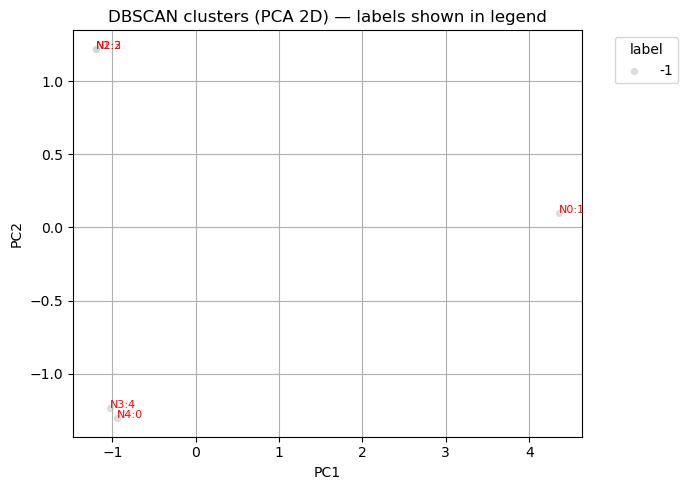


Actionable hints:
- If noise points have much larger k-dist than cluster members: increase eps or reduce min_samples.
- If noise differ mainly on one feature (check display above), consider re-scaling or transforming that feature.
- If cluster 5 disappeared: it may be merged into noise because eps is too small for that density; try eps += 0.1 or min_samples -= 1 (experiment).
- To inspect a specific agg row in detail, set idx = <agg_index> and run: display(agg.loc[[idx]]); then map back to raw df using group keys if available.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from IPython.display import display

# Safety checks
assert 'agg' in globals(), "agg not found"
assert 'labels_db' in globals(), "labels_db not found"
assert 'X_scaled' in globals(), "X_scaled not found"

print("DBSCAN label counts:")
print(pd.Series(labels_db).value_counts().sort_index())

# show top examples for noise (-1) and cluster 5 (if present)
for lab in [-1, 5]:
    present = lab in np.unique(labels_db)
    print(f"\nLabel {lab} present: {present}")
    if present:
        mask = agg['dbscan_label'] == lab
        print(f"Rows in agg with label {lab}: {mask.sum()}")
        display(agg.loc[mask].sort_values(by='rows', ascending=False).head(8))

# compute k-distances (n_neighbors = min_samples)
n_neighbors = max(2, getattr(db, 'min_samples', 5))
nn = NearestNeighbors(n_neighbors=n_neighbors).fit(X_scaled)
distances, neigh_idxs = nn.kneighbors(X_scaled)
kdist = distances[:, -1]

# attach kdist to agg copy (preserve original)
agg_k = agg.copy().reset_index(drop=True)
agg_k['kdist'] = kdist

# summary stats for kdist by label
print("\nk-dist summary by dbscan_label:")
print(agg_k.groupby('dbscan_label')['kdist'].agg(['count','mean','median','max']).sort_values('mean', ascending=False).head(10))

# If cluster 5 is missing, list top labels by mean kdist
if 5 not in agg_k['dbscan_label'].unique():
    print("\nCluster 5 not present. Top labels by mean kdist (likely isolated/noisy groups):")
    display(agg_k.groupby('dbscan_label')['kdist'].mean().sort_values(ascending=False).head(8).to_frame('mean_kdist'))

# Show nearest neighbors' labels for top noise points
if -1 in agg_k['dbscan_label'].values:
    top_noise = agg_k[agg_k['dbscan_label'] == -1].sort_values('kdist', ascending=False).head(6)
    print("\nTop noise groups (by kdist) and their nearest neighbors' labels/distances:")
    rows = []
    for idx in top_noise.index:
        nbr_idxs = neigh_idxs[idx]
        nbr_labels = labels_db[nbr_idxs]
        nbr_dists = distances[idx]
        rows.append({
            'agg_index': idx,
            'kdist': float(kdist[idx]),
            'nearest_labels': nbr_labels.tolist(),
            'nearest_dists': np.round(nbr_dists.tolist(), 4)
        })
    display(pd.DataFrame(rows))

    # Map back to original df using group keys if possible
    group_keys = [c for c in agg.columns if c in df.columns]
    if group_keys:
        print("\nMapping top noise groups back to raw df (first 20 rows): group keys =", group_keys)
        noise_keys = agg_k.loc[top_noise.index, group_keys].drop_duplicates()
        sample_noise_rows = df.merge(noise_keys, on=group_keys, how='inner').head(20)
        display(sample_noise_rows)
    else:
        print("\nNo group keys available to map back to raw rows (agg was global).")

# PCA plot with highlights: noise vs cluster 5 vs others
pca = PCA(n_components=2, random_state=0)
XY = pca.fit_transform(X_scaled)
plt.figure(figsize=(7,5))
unique_labs = np.unique(labels_db)
colors = { -1: 'lightgray' }
colors.update({lab: plt.cm.tab10(i % 10) for i, lab in enumerate([l for l in unique_labs if l != -1])})
for lab in unique_labs:
    mask = labels_db == lab
    plt.scatter(XY[mask,0], XY[mask,1], s=18, color=colors.get(lab, 'k'), label=f'{lab}', alpha=0.7)
# annotate top noise points
if -1 in agg_k['dbscan_label'].values:
    top_idx = agg_k[agg_k['dbscan_label'] == -1].sort_values('kdist', ascending=False).head(6).index
    for i, idx in enumerate(top_idx):
        plt.annotate(f'N{i}:{idx}', (XY[idx,0], XY[idx,1]), fontsize=8, color='red')
plt.title('DBSCAN clusters (PCA 2D) — labels shown in legend')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(title='label', bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True); plt.tight_layout(); plt.show()

# Quick actionable hints
print("\nActionable hints:")
print("- If noise points have much larger k-dist than cluster members: increase eps or reduce min_samples.")
print("- If noise differ mainly on one feature (check display above), consider re-scaling or transforming that feature.")
print("- If cluster 5 disappeared: it may be merged into noise because eps is too small for that density; try eps += 0.1 or min_samples -= 1 (experiment).")
print("- To inspect a specific agg row in detail, set idx = <agg_index> and run: display(agg.loc[[idx]]); then map back to raw df using group keys if available.")

## 4) HDBSCAN (if available)

In [ ]:
try:
    import hdbscan
    HAS_HDBSCAN = True
except Exception as e:
    HAS_HDBSCAN = False
    print("HDBSCAN not available:", e)

if HAS_HDBSCAN:
    clusterer = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=5)
    labels_hdb = clusterer.fit_predict(X_scaled)
    agg['hdbscan_label'] = labels_hdb
    try:
        agg['hdb_outlier_score'] = clusterer.outlier_scores_
    except Exception:
        agg['hdb_outlier_score'] = 0.0
    print(agg['hdbscan_label'].value_counts().sort_index())
else:
    # graceful fallback when hdbscan isn't installable in the environment
    # if DBSCAN ran earlier, reuse those labels; otherwise mark as unavailable (-2)
    if 'dbscan_label' in agg.columns:
        agg['hdbscan_label'] = agg['dbscan_label']
    else:
        agg['hdbscan_label'] = -2
    agg['hdb_outlier_score'] = 0.0
    print("HDBSCAN not available; using fallback hdbscan_label (copied dbscan_label if present).")

HDBSCAN not available: No module named 'hdbscan'
HDBSCAN not available; using fallback hdbscan_label (copied dbscan_label if present).


## 5) Compare results & draft detection rules

In [ ]:
import numpy as np, yaml
summary = {
    "rows_in_agg": int(agg.shape[0]),
    "dbscan_clusters": int(agg['dbscan_label'].nunique() - (1 if (-1 in agg['dbscan_label'].unique()) else 0)),
    "dbscan_noise": int((agg['dbscan_label'] == -1).sum())
}
if 'hdbscan_label' in agg.columns:
    valid_hdb = len([c for c in agg['hdbscan_label'].unique() if c >= 0])
    summary["hdbscan_clusters"] = int(valid_hdb)
    summary["hdbscan_noise"] = int((agg['hdbscan_label'] == -1).sum())
summary

In [17]:
# Simple thresholds from empirical p50/p75/p90/p95 (robust to NaN / non-numeric)
import numpy as np
import pandas as pd

candidates = ['queries','mean_entropy','failed_ratio','rows']
thr = {}
summary = {}

for c in candidates:
    if c not in agg.columns:
        continue
    # safe numeric conversion and drop NaNs
    vals = pd.to_numeric(agg[c], errors='coerce').dropna()
    cnt = len(vals)
    if cnt == 0:
        print(f"Warning: column {c} exists but has no numeric values")
        continue
    # compute multiple percentiles to help tuning
    p = np.nanpercentile(vals, [50, 75, 90, 95])
    summary[c] = {'count': int(cnt), 'p50': float(p[0]), 'p75': float(p[1]), 'p90': float(p[2]), 'p95': float(p[3])}
    # default threshold = p95
    thr[c] = float(p[3])

# show results
if not summary:
    print("No candidate columns found in agg. Available columns:", list(agg.columns))
else:
    display(pd.DataFrame(summary).T)

thr


,count,p50,p75,p90,p95
queries,5.0,426.000000,473.000000,957.800000,1119.400000
mean_entropy,5.0,3.738339,3.759128,3.759128,3.759128
failed_ratio,5.0,0.000000,0.000000,0.000000,0.000000
rows,5.0,426.000000,473.000000,957.800000,1119.400000


{'queries': 1119.3999999999999,
 'mean_entropy': 3.7591278187174493,
 'failed_ratio': 0.0,
 'rows': 1119.3999999999999}

### Sigma rule candidate (generic)

In [17]:
sigma = {
  "title": "Unusual Activity (Cluster-derived thresholds)",
  "id": "cluster-derived-unusual-activity",
  "status": "experimental",
  "description": "Detect points consistent with rare-event clusters (high volume / entropy / failures).",
  "logsource": {"product": "zeek", "service": "dns"},
  "detection": {"selection": {}, "condition": "selection"},
  "falsepositives": ["Legitimate resolvers, CDN/update bursts"],
  "level": "high"
}
for k,v in thr.items():
    sigma["detection"]["selection"][k] = {"min": float(round(v,3))}
sigma_path = "./sigma_cluster_candidate.yml"
import yaml
with open(sigma_path, "w") as f:
    yaml.safe_dump(sigma, f, sort_keys=False)
print("Sigma rule written to:", sigma_path)
sigma

Sigma rule written to: ./sigma_cluster_candidate.yml


{'title': 'Unusual Activity (Cluster-derived thresholds)',
 'id': 'cluster-derived-unusual-activity',
 'status': 'experimental',
 'description': 'Detect points consistent with rare-event clusters (high volume / entropy / failures).',
 'logsource': {'product': 'zeek', 'service': 'dns'},
 'detection': {'selection': {'queries': {'min': 1119.4},
   'mean_entropy': {'min': 3.759},
   'failed_ratio': {'min': 0.0},
   'rows': {'min': 1119.4}},
  'condition': 'selection'},
 'falsepositives': ['Legitimate resolvers, CDN/update bursts'],
 'level': 'high'}

In [18]:
# ...existing code...
# Cell: export practical Sigma rules + suspicious IP list (run after clustering cells)
import yaml, json, numpy as np

# pick IP field that was used for grouping or fall back
ip_field = next((c for c in ['src_ip','source.ip','client.ip','id.orig_h','network.client.ip'] if c in agg.columns), None)
if ip_field is None:
    ip_field = 'source.ip'  # generic sigma field

# collect suspicious IPs from DBSCAN noise (or choose cluster number you care about, e.g., 5)
sus_ips = []
if 'dbscan_label' in agg.columns and ip_field in agg.columns:
    sus_ips = agg.loc[agg['dbscan_label'] == -1, ip_field].dropna().astype(str).unique().tolist()

# fallback: pick top N groups by rows if no noise IPs found
if not sus_ips:
    if ip_field in agg.columns and 'rows' in agg.columns:
        sus_ips = agg.sort_values('rows', ascending=False).head(20)[ip_field].dropna().astype(str).unique().tolist()

# build sigma using inline IP list + numeric threshold (queries p95 if present in thr)
q_thr = thr.get('queries') if isinstance(thr, dict) else None

sigma_ips = {
  "title": "Anomalous DNS source IPs (cluster-derived)",
  "id": "cluster-derived-anom-ips",
  "status": "experimental",
  "description": "Alert when source IP matches IPs flagged as anomalous by DBSCAN offline job.",
  "logsource": {"product":"zeek","service":"dns"},
  "detection": {
      "selection": {
          ip_field: sus_ips
      },
      "condition": "selection"
  },
  "falsepositives": ["Known legitimate resolvers, scanning infrastructure"],
  "level": "high"
}

sigma_thresh = {
  "title": "High DNS query volume (cluster-derived p95)",
  "id": "cluster-derived-high-queries",
  "status": "experimental",
  "description": "Alert when queries in an aggregation exceed the cluster-derived threshold (p95).",
  "logsource": {"product":"zeek","service":"dns"},
  "detection": {
      "selection": {},
      "condition": "selection"
  },
  "falsepositives": ["Bursts from CDNs/resolvers"],
  "level": "medium"
}
if q_thr is not None:
    sigma_thresh["detection"]["selection"]["queries"] = {"gte": float(round(q_thr,3))}
else:
    # if no computed threshold, use a conservative default to avoid noisy alerts
    sigma_thresh["detection"]["selection"]["queries"] = {"gte": 100.0}

# combined rule: IP OR threshold (useful if you want single rule)
sigma_combined = {
  "title": "Cluster-derived DNS anomalies (IP list OR volume)",
  "id": "cluster-derived-combined",
  "status": "experimental",
  "description": "Combined rule: source IP in offline-anom-list OR queries exceed p95.",
  "logsource": {"product":"zeek","service":"dns"},
  "detection": {
      "selection_ip": { ip_field: sus_ips },
      "selection_q": { "queries": {"gte": float(round(q_thr,3))} } if q_thr is not None else {"queries": {"gte": 100.0}},
      "condition": "selection_ip or selection_q"
  },
  "falsepositives": ["Legit bursts, resolvers"],
  "level": "high"
}

# write files
with open("./sigma_ips.yml", "w") as f:
    yaml.safe_dump(sigma_ips, f, sort_keys=False)
with open("./sigma_queries.yml", "w") as f:
    yaml.safe_dump(sigma_thresh, f, sort_keys=False)
with open("./sigma_combined.yml", "w") as f:
    yaml.safe_dump(sigma_combined, f, sort_keys=False)
with open("./suspicious_ips.txt", "w") as f:
    f.write("\\n".join(sus_ips))

print("Wrote: sigma_ips.yml, sigma_queries.yml, sigma_combined.yml, suspicious_ips.txt")
print(f"IP field used: {ip_field}; suspicious IPs: {len(sus_ips)}")
# ...existing code...

Wrote: sigma_ips.yml, sigma_queries.yml, sigma_combined.yml, suspicious_ips.txt
IP field used: source.ip; suspicious IPs: 5


### IDS/Firewall examples (illustrative)

- **Suricata/IDS threshold rule:**
  ```
  alert dns any any -> any any (msg:"Suspicious DNS volume (cluster-derived)";
    threshold: type both, track by_src, count <queries_p95>, seconds 3600; sid:1100001; rev:1;)
  ```
- **Firewall/SOAR playbook:**
  - Rate-limit or alert when host exceeds baseline (p95) sustained over 15–60 min.
  - Enrich rare clusters (domains/IPs) with VT/WHOIS; auto-suppress known-good infra.
